In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from sklearn.cluster import KMeans
from sklearn import svm
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import r2_score
from typing import Sequence
from dataclasses import dataclass
from typing import NamedTuple
from typing import Mapping
from typing import TypeAlias
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.optimize import minimize

sys.path.append('C:/Users/evils/PycharmProjects/approximationMap')

from control.experiment_data import ExperimentData

In [4]:
"""АННОТАЦИЯ ТИПОВ"""
FuelCombination: TypeAlias = str

class ApproxData(NamedTuple):
    """Аппроксимированная поверхность со значением расхода топлива и вводимого компонента"""
    fuel_consumption: np.ndarray
    additive_consumption: np.ndarray
    approximated_surface: np.ndarray

class DiffData(NamedTuple):
    """Дифференциальная поверхность со значением расхода топлива и вводимого компонента"""
    fuel_consumption: np.ndarray
    additive_consumption: np.ndarray
    diff_surface: np.ndarray

class MinPoints(NamedTuple):
    """Координаты минимимальных значений каждой строки в матрице"""
    x: np.ndarray
    y: np.ndarray

class LinearCoeffs(NamedTuple):
    """Коэффициенты линейной прямой"""
    angular_coefficient: float  # Угловой коэффицент
    b: float

class LevelPoints(NamedTuple):
    """Координаты выбранного уровне contourf"""
    x: np.ndarray
    y: np.ndarray

"""ОШИБКИ"""

def fuel_combination_key_error() -> KeyError:
    return KeyError('Сочетание топлива, добавки и компонента не найдено в словаре!')

"""ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ"""

def get_fuels_combinations(CO=True) -> list[FuelCombination]:
    if CO:
        fuel_combinations = [
            'diesel_steam_CO',
            'crude_oil_steam_CO',
            'heavy_oil_steam_CO',
            'kerosene_steam_CO',
            'waste_oil_steam_CO',
            'waste_oil_40_2024_steam_CO',
            'waste_oil_60_2024_steam_CO',
            'MEFA_rapeseed_oil_steam_CO',
            'MEFA_tall_oil_steam_CO'
        ]
    else:
        fuel_combinations = [
            'diesel_steam_O2',
            'crude_oil_steam_O2',
            'heavy_oil_steam_O2',
            'kerosene_steam_O2',
            'waste_oil_steam_O2',\
        ]
    return fuel_combinations

def title_on_russian(title: str) -> str:
    translate = {
        'diesel': 'Дизельное топливо',
        'diesel, CO': 'Дизельное топливо, CO',
        'diesel_steam_CO': 'Дизельное топливо, CO',
        'crude_oil_steam_CO': 'Сырая нефть, CO',
        'heavy_oil_steam_CO': 'Мазут, CO',
        'kerosene_steam_CO': 'Керосин, CO',
        'waste_oil_steam_CO': 'Отработанное масло, CO'
    }
    return translate.get(title, title)

"""ПОЛУЧЕНИЕ ПОВЕРХНОСТЕЙ"""

def get_rbf_data(CO=True) -> Mapping[FuelCombination, ApproxData]:
    fuel_combinations = get_fuels_combinations(CO=CO)
    rbf_data = {}
    
    for fuel_combination in fuel_combinations:
        ex = ExperimentData()
        ex.get_experiment_data(*delete_underline(fuel_combination))
        rbf_data[fuel_combination] = ex.get_rbf_data()
    return rbf_data

def get_diff_data(CO=True) -> Mapping[FuelCombination, DiffData]:
    rbf_data = get_rbf_data(CO=CO)
    diff_data = {}
    for fuel_combination in rbf_data:
        fuel_cons, add_cons, surf = rbf_data[fuel_combination]

        diff = np.abs(surf[5:] - surf[:-5])
        add_cons_diff = add_cons[5:]
        diff_data[fuel_combination] = fuel_cons, add_cons_diff, diff
    return diff_data


def get_diff_data(CO=True) -> Mapping[FuelCombination, DiffData]:
    rbf_data = get_rbf_data(CO=CO)
    diff_data = {}
    for fuel_combination in rbf_data:
        fuel_cons, add_cons, surf = rbf_data[fuel_combination]

        diff = np.abs(surf[:, 0:95] - surf[:, 5:100])
        fuel_cons_diff = fuel_cons[5:]
        diff_data[fuel_combination] = fuel_cons_diff, add_cons, diff
    return diff_data



"""ЛИНИЯ МИНИМАЛЬНЫХ КОНЦЕНТРАЦИЙ CO"""

def _get_min_CO(data: Mapping[FuelCombination, ApproxData]) -> Mapping[FuelCombination, MinPoints]:
    """В апроксимированной матрице находит минимальные значения в каждой строке матрицы"""
    min_CO = {}
    
    for fuel_combination in data:
        fuel, additive, surf = data[fuel_combination]
        df = pd.DataFrame(surf, columns=fuel, index=additive)
        df = df.idxmin(axis=1)
        min_x = list(df)
        min_y = list(df.index)
        min_CO[fuel_combination] = min_x, min_y
    return min_CO

def _linear(x, a, b):
    return a * x + b
    
def rotate_line(a: float, b: float, angle: float, mid_x: float, offset: int=0) -> tuple:
    theta = np.radians(angle)
    
    mid_y = a * mid_x + b
    
    new_a = a * np.cos(theta) - (mid_y - b) * np.sin(theta)
    new_b = mid_y - new_a * mid_x - offset  # Включаем смещение
    
    return new_a, new_b

def get_linear_coeffs_min_CO() -> Mapping[FuelCombination, LinearCoeffs]:
    rbf_data = get_rbf_data(CO=True)
    min_CO = _get_min_CO(rbf_data)
    coeffs = {}
    
    # Задайте углы поворота для определённых fuel_combination
    rotation_angles = {
        'waste_oil_steam_CO': 5,
        'waste_oil_40_2024_steam_CO': 17,
        'waste_oil_60_2024_steam_CO': 17
    }
    fuels_to_offset = {
        'waste_oil_steam_CO': 0.025,
        'waste_oil_60_2024_steam_CO': 0.1
    }
        
    for fuel_combination in min_CO:
        min_x, min_y = min_CO[fuel_combination]
        params, _ = curve_fit(_linear, min_x, min_y)
        a, b = params
        
        # Вычисляем середину для поворота
        mid_x = (min_x[0] + min_x[-1]) / 2
        
        # Если комбинация топлива в словаре, примените поворот
        if fuel_combination in rotation_angles:
            angle = rotation_angles[fuel_combination]
            if fuel_combination in fuels_to_offset:
                 a, b = rotate_line(a, b, angle, mid_x, offset=fuels_to_offset[fuel_combination])
            else:
                a, b = rotate_line(a, b, angle, mid_x)

        coeffs[fuel_combination] = a, b
    
    return coeffs

def delete_underline(string_with_underline: str) -> tuple:
    parts = string_with_underline.split('_')
    # Находим индекс "steam" и объединяем все части до него
    steam_index = parts.index('steam')
    fuel_name = '_'.join(parts[:steam_index])
    return (fuel_name, parts[steam_index], parts[steam_index + 1])

"""ЛИНИИ МАКСИМАЛЬНОГО ГРАДИЕНТА"""

def get_contours(data: Mapping[FuelCombination, ApproxData | DiffData], contour_level) -> Mapping[FuelCombination, LevelPoints]:
    level_data = {}
        
    for fuel_combination in data:
        fig, ax = plt.subplots()
        
        x, y, surf = data[fuel_combination]
        contours = plt.contourf(x, y, surf, colors='none')
        '''
        if fuel_combination == 'waste_oil_60_2024_steam_CO':
            contour_level = 2
        '''
            
        selected_contour = contours.collections[contour_level]
        path = selected_contour.get_paths()[0]
        points = path.vertices

        level_x, level_y = points[:, 0], points[:, 1]
        level_data[fuel_combination] = level_x, level_y

        ax.remove()
        plt.close(fig)
    return level_data

def _classify_by_line(MinPoints, LinearCoeffs) -> np.array:
    x, y = MinPoints
    a, b = LinearCoeffs
    result = y - a * x - b
    
    classification = np.where(result > 0, 1, 2)
    return classification

def _get_class(x: np.ndarray, y: np.ndarray, predicted_class: np.ndarray, class_number: int) -> LevelPoints:
    x_selected = []
    y_selected = []
    
    for i in range(len(predicted_class)):
        if predicted_class[i] == class_number:
            x_selected.append(x[i])
            y_selected.append(y[i])
    return np.array(x_selected), np.array(y_selected)

def get_linear_coeffs_div_line(data: Mapping[FuelCombination, DiffData], contour_level: int, cls: int=2) -> Mapping[FuelCombination, MinPoints]:
    data = get_rbf_data(CO=True)
    linear_coeffs = {}
    min_coeffs = get_linear_coeffs_min_CO()
    contour_data = get_contours(data, contour_level)

    # Задайте углы поворота для определённых fuel_combination
    '''
    rotation_angles = {
        'diesel_steam_CO': 0,
        'kerosene_steam_CO': 20,
        'waste_oil_steam_CO': 0,
        'waste_oil_40_2024_steam_CO': 10,
        'waste_oil_60_2024_steam_CO': 15
    }
    fuels_to_offset = {
        'diesel_steam_CO': 0.05,
        'kerosene_steam_CO': -0.4,
        'waste_oil_steam_CO': 0.1,
        'waste_oil_40_2024_steam_CO': 0.07,
        'waste_oil_60_2024_steam_CO': -0.1
    }
    '''
    rotation_angles = {
        'diesel_steam_CO': 8,
        'kerosene_steam_CO': 0,
        'heavy_oil_steam_CO': 5,
        'waste_oil_steam_CO': 0,
        'waste_oil_40_2024_steam_CO': 0,
        'waste_oil_60_2024_steam_CO': 15
    }
    fuels_to_offset = {
        'diesel_steam_CO': -0.05,
        'kerosene_steam_CO': 0,
        'heavy_oil_steam_CO': -0.1,
        'waste_oil_steam_CO': 0,
        'waste_oil_40_2024_steam_CO': 0.05,
        'waste_oil_60_2024_steam_CO': -0.3
    }
    
    for fuel_combination in data:
        x, y, surf = data[fuel_combination]
        a, b = min_coeffs[fuel_combination]
        x_level, y_level = contour_data[fuel_combination]
        
        classified = _classify_by_line((x_level, y_level), (a, b))
        x_selected, y_selected = _get_class(x_level, y_level, classified, cls)
        params, _ = curve_fit(_linear, x_selected, y_selected)
        a, b = params

        # Вычисляем середину для поворота
        mid_x = (x[0] + x[-1]) / 2
        
        # Если комбинация топлива в словаре, примените поворот
        if fuel_combination in rotation_angles:
            angle = rotation_angles[fuel_combination]
            if fuel_combination in fuels_to_offset:
                 a, b = rotate_line(a, b, angle, mid_x, offset=fuels_to_offset[fuel_combination])
            else:
                a, b = rotate_line(a, b, angle, mid_x)
        
        linear_coeffs[fuel_combination] = a, b
        
    return linear_coeffs

def show_contours(data: Mapping[FuelCombination, DiffData], contour_level) -> None:
    contour_data = get_contours(data, contour_level)
        
    for fuel_combination in data:
        x, y, surf = data[fuel_combination]
        x_level, y_level = contour_data[fuel_combination]
        plt.title(fuel_combination)
        plt.contourf(x, y, surf)

        plt.scatter(x_level, y_level, c='black')
        plt.show()
        plt.close()

"""СРЕДНЕЕ"""
def get_mean_coeffs(
    grad_coeffs: Mapping[FuelCombination, LinearCoeffs], 
    min_coeffs: Mapping[FuelCombination, LinearCoeffs]
) -> Mapping[FuelCombination, LinearCoeffs]:
    coeffs = {}
    
    for fuel_combination in min_coeffs:
        a = (grad_coeffs[fuel_combination][0] + min_coeffs[fuel_combination][0]) / 2
        b = (grad_coeffs[fuel_combination][1] + min_coeffs[fuel_combination][1]) / 2
        coeffs[fuel_combination] = a, b
    return coeffs

C:\Users\evils\AppData\Local\Temp\ipykernel_1040\3678048584.py:196: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


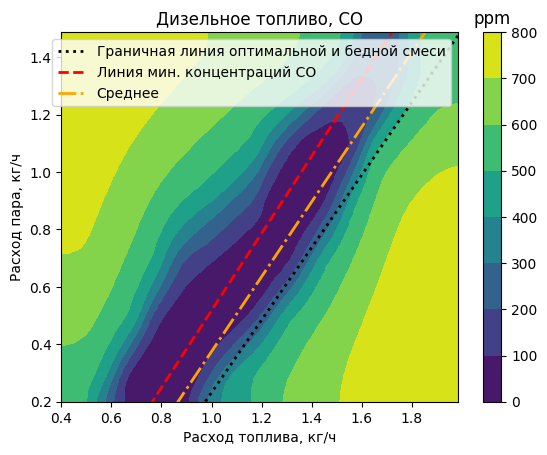

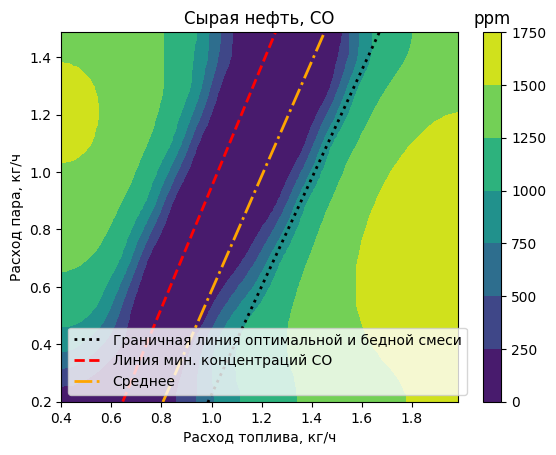

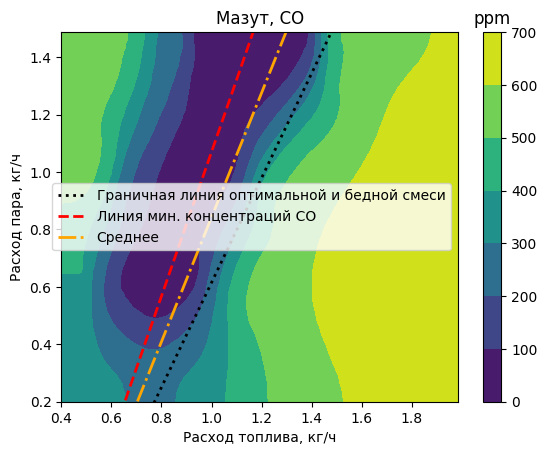

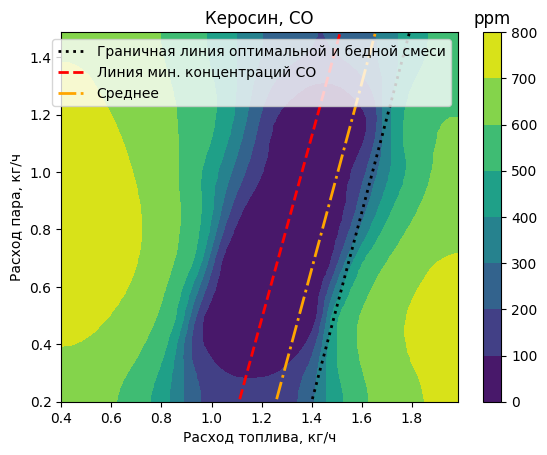

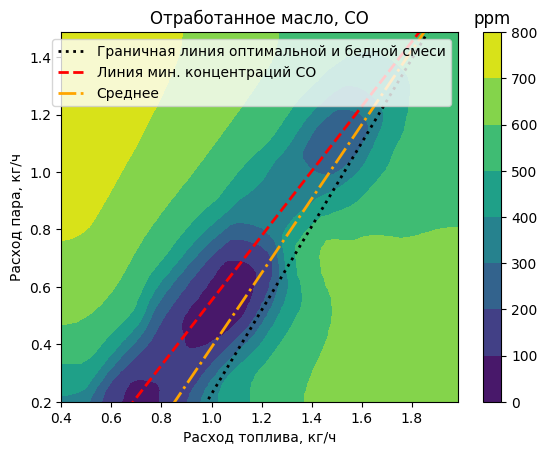

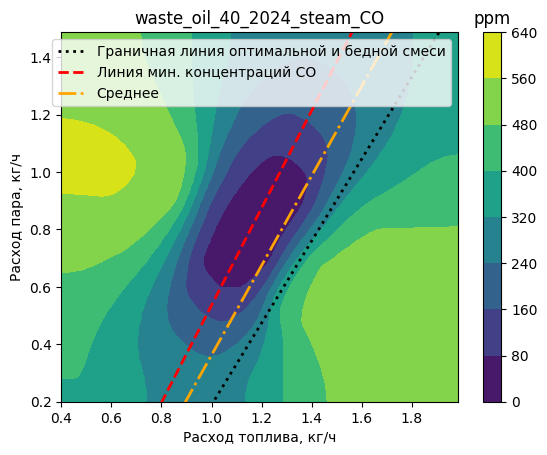

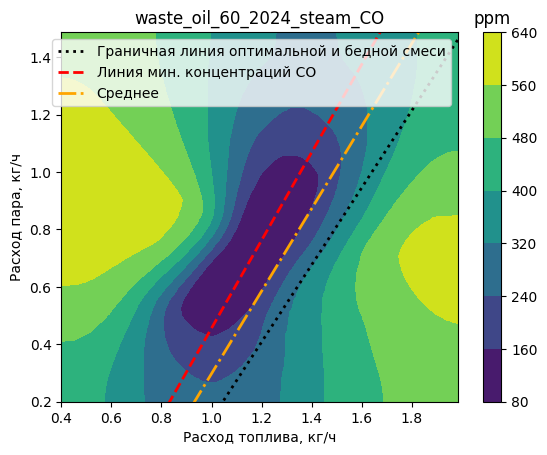

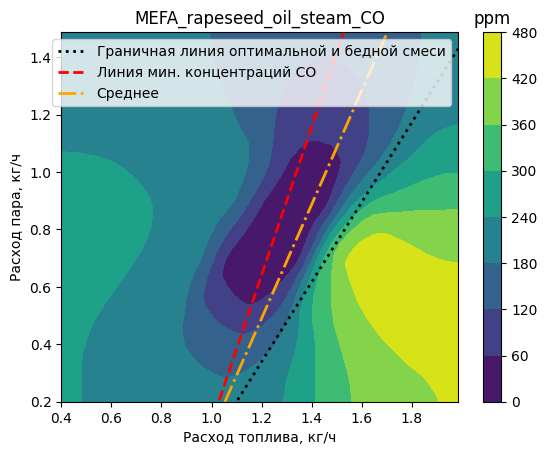

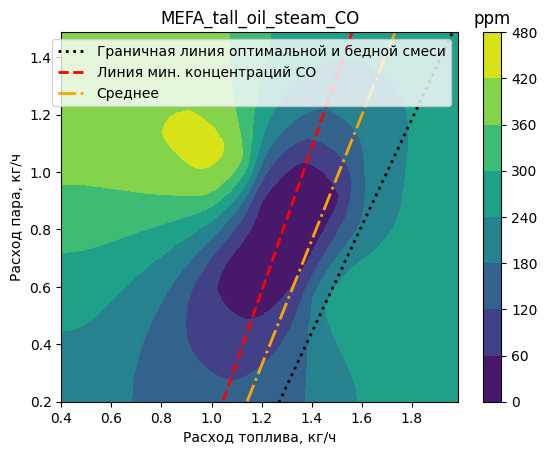

In [5]:
rbf_data = get_rbf_data()
min_CO_coeffs = get_linear_coeffs_min_CO()
diff_data = get_diff_data()
div_line_coeffs_high_line = get_linear_coeffs_div_line(diff_data, 3)
mean_coeffs = get_mean_coeffs(div_line_coeffs_high_line, min_CO_coeffs)

for fuel_combination in rbf_data:
    fuel_cons, add_cons_diff, diff = rbf_data[fuel_combination]
    grad_approx = _linear(fuel_cons, *div_line_coeffs_high_line[fuel_combination])
    min_approx = _linear(fuel_cons, *min_CO_coeffs[fuel_combination])
    mean_approx = _linear(fuel_cons, *mean_coeffs[fuel_combination])
    
    fig, ax = plt.subplots()
    plt.contourf(fuel_cons, add_cons_diff, diff)
    plt.plot(fuel_cons, grad_approx, c='black', linestyle='dotted', linewidth=2, label='Граничная линия оптимальной и бедной смеси')
    plt.plot(fuel_cons, min_approx, c='red', linestyle='dashed', linewidth=2, label='Линия мин. концентраций CO')
    plt.plot(fuel_cons, mean_approx, c='orange', linestyle='dashdot', linewidth=2, label='Среднее')
    clb = plt.colorbar()
    clb.ax.set_title('ppm')
    ax.set_xlabel('Расход топлива, кг/ч')
    ax.set_ylabel('Расход пара, кг/ч')
    plt.legend()
    plt.ylim(min(add_cons_diff), max(add_cons_diff))
    plt.title(title_on_russian(fuel_combination))
    plt.show()
    plt.close()